In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold


   Study_Hours  Attendance  Assignment_Scores
0            1          80                 50
1            2          85                 55
2            3          90                 58
3            4          75                 62
4            5          95                 65
0    32
1    45
2    50
3    55
4    60
Name: Final Marks, dtype: int64
Intercept: 61.5
Coefficients:
             Feature  Coefficient
0        Study_Hours     7.607378
1         Attendance     0.005250
2  Assignment_Scores     6.591720
Model Score: 0.9981927240796523
Actual values: [80 45]
Predicted values: [80.26218443 43.98107124]
             Feature  Coefficient
0        Study_Hours     7.607378
1         Attendance     0.005250
2  Assignment_Scores     6.591720
Predicted final marks for new student: 66.2811884404823


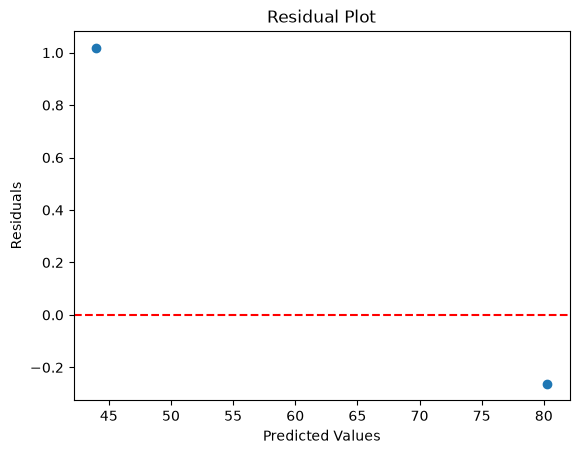

In [4]:
data1 = {
    'Study_Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Attendance': [80, 85, 90, 75, 95, 70, 60, 85, 90, 95],
    'Assignment_Scores': [50, 55, 58, 62, 65, 71, 75, 80, 85, 90],
    'Final Marks': [32, 45, 50, 55, 60, 65, 70, 75, 80, 85]
}

df = pd.DataFrame(data1)

x = df[['Study_Hours', 'Attendance', 'Assignment_Scores']]
y = df['Final Marks']

print(x.head())
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

print("Intercept:", ridge_model.named_steps['ridge'].intercept_)
print("Coefficients:")
print(pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': ridge_model.named_steps['ridge'].coef_
}))

print("Model Score:", ridge_model.score(X_test, y_test))

y_pred = ridge_model.predict(X_test)
print("Actual values:", y_test.values)
print("Predicted values:", y_pred)

coefficient_table = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': ridge_model.named_steps['ridge'].coef_
})
print(coefficient_table)

new_student = pd.DataFrame({
    'Study_Hours': [6],
    'Attendance': [80],
    'Assignment_Scores': [75]
})

prediction = ridge_model.predict(new_student)
print("Predicted final marks for new student:", prediction[0])

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()


In [7]:
data1 = {
    'Study_Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Attendance': [80, 85, 90, 75, 95, 70, 60, 85, 90, 95],
    'Assignment_Scores': [50, 55, 58, 62, 65, 71, 75, 80, 85, 90],
    'Final Marks': [32, 45, 50, 55, 60, 65, 70, 75, 80, 85]
}

df = pd.DataFrame(data1)

x = df[['Study_Hours', 'Attendance', 'Assignment_Scores']]
y = df['Final Marks']

print(x.head())
print(y.head())

   Study_Hours  Attendance  Assignment_Scores
0            1          80                 50
1            2          85                 55
2            3          90                 58
3            4          75                 62
4            5          95                 65
0    32
1    45
2    50
3    55
4    60
Name: Final Marks, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
ridge_cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridgecv', RidgeCV(alphas=[0.1, 1.0, 10.0]))
])

ridge_cv_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridgecv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Study_Hours','Attendance','Assignment_Scores']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [10]:
print('Best Alpha:', ridge_cv_model.named_steps['ridgecv'].alpha_)
print('Intercept:', ridge_cv_model.named_steps['ridgecv'].intercept_)
print('Coefficients:')
print(pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': ridge_cv_model.named_steps['ridgecv'].coef_
}))

print('Model Score:', ridge_cv_model.score(X_test, y_test))

Best Alpha: 0.1
Intercept: 61.5
Coefficients:
             Feature  Coefficient
0        Study_Hours    11.814528
1         Attendance    -0.035134
2  Assignment_Scores     3.182613
Model Score: 0.9873304311377579


In [11]:
y_pred = ridge_cv_model.predict(X_test)
print('Actual values:', y_test.values)
print('Predicted values:', y_pred)

Actual values: [80 45]
Predicted values: [81.11340087 42.44648293]


In [12]:
coefficient_table = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': ridge_cv_model.named_steps['ridgecv'].coef_
})
print(coefficient_table)

new_student = pd.DataFrame({
    'Study_Hours': [6],
    'Attendance': [80],
    'Assignment_Scores': [75]
})

prediction = ridge_cv_model.predict(new_student)
print('Predicted final marks for new student:', prediction[0])

             Feature  Coefficient
0        Study_Hours    11.814528
1         Attendance    -0.035134
2  Assignment_Scores     3.182613
Predicted final marks for new student: 65.32433614435257


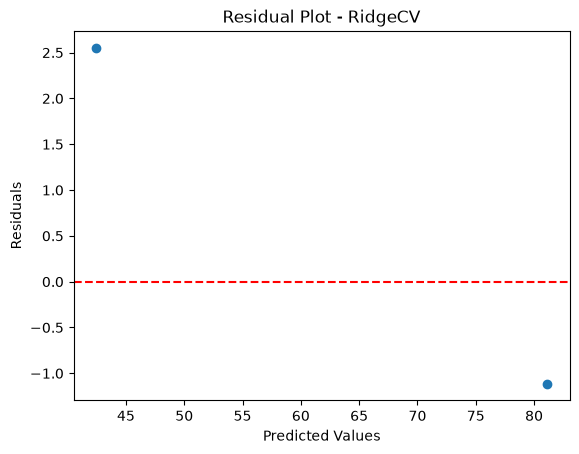

In [13]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot - RidgeCV')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [ ]:
data = {
    "Hours_Studied": [2,4,6,8,10],
    "Class_Attended": [3,5,7,9,11],
    "Final_Score": [50, 60, 70, 80, 90]
}


#Use First Multiple Linear Regression Model and Then Ridge Regression Model to Compare the Results and See the Difference in Coefficients and Predictions.